In [1]:
import pandas as pd
import requests

In [2]:
response = requests.get("https://dummyjson.com/users?limit=100")
data = response.json()
df = pd.DataFrame(data['users'])
df.head()
df.to_json("data/users.json", orient="records", indent=4)

## Data Exploration

In [7]:
print(df.shape)
print(df.columns)
print(df.dtypes)
print(df.isnull().sum())
simple_cols = [col for col in df.columns if df[col].apply(type).eq(dict).any() == False]
print(df[simple_cols].duplicated().sum())
print(df.describe())



(100, 29)
Index(['id', 'firstName', 'lastName', 'maidenName', 'age', 'gender', 'email',
       'phone', 'username', 'password', 'birthDate', 'image', 'bloodGroup',
       'height', 'weight', 'eyeColor', 'hair', 'ip', 'address', 'macAddress',
       'university', 'bank', 'company', 'ein', 'ssn', 'userAgent', 'crypto',
       'role', 'country'],
      dtype='str')
id              int64
firstName         str
lastName          str
maidenName        str
age             int64
gender            str
email             str
phone             str
username          str
password          str
birthDate         str
image             str
bloodGroup        str
height        float64
weight        float64
eyeColor          str
hair           object
ip                str
address        object
macAddress        str
university        str
bank           object
company        object
ein               str
ssn               str
userAgent         str
crypto         object
role              str
country           s

In [5]:
# Value count 
print(df['gender'].value_counts())
print(df['bloodGroup'].value_counts())
print(df['eyeColor'].value_counts())

df['country'] = df['address'].apply(lambda x: x['country'])
print(df['country'].value_counts().head(10))

print(df[['age','height','weight']].isnull().sum())


gender
female    52
male      48
Name: count, dtype: int64
bloodGroup
O-     19
A+     15
AB+    13
AB-    13
B+     12
B-     10
O+     10
A-      8
Name: count, dtype: int64
eyeColor
Brown     18
Hazel     16
Gray      14
Red       12
Blue      12
Green     11
Amber     10
Violet     7
Name: count, dtype: int64
country
United States    100
Name: count, dtype: int64
age       0
height    0
weight    0
dtype: int64


## Data Cleaning

In [8]:
df['city'] = df['address'].apply(lambda x: x['city'])
df['country'] = df['address'].apply(lambda x: x['country'])

In [9]:
df['age'] = df['age'].fillna(df['age'].mean())
df['height'] = df['height'].fillna(df['height'].mean())
df['weight'] = df['weight'].fillna(df['weight'].mean())

In [43]:
df['company_name'] = df['company'].apply(lambda x: x['name'])
df['department'] = df['company'].apply(lambda x: x['department'])


## Data Analysis

In [10]:
avg_age = df['age'].mean()
print("Average age:", avg_age)

Average age: 31.7


In [11]:
avg_age_gender = df.groupby('gender')['age'].mean()
print("\nAverage age by gender:\n", avg_age_gender)


Average age by gender:
 gender
female    29.730769
male      33.833333
Name: age, dtype: float64


In [12]:
gender_counts = df['gender'].value_counts()
print("\nNumber of users per gender:\n", gender_counts)


Number of users per gender:
 gender
female    52
male      48
Name: count, dtype: int64


In [13]:
top_cities = df['city'].value_counts().head(10)
print("\nTop 10 cities:\n", top_cities)


Top 10 cities:
 city
Phoenix         9
Jacksonville    8
Columbus        8
Dallas          8
San Diego       6
Chicago         6
Seattle         5
San Antonio     5
New York        5
Denver          5
Name: count, dtype: int64


In [14]:
avg_height_weight = df[['height','weight']].mean()
print("\nAverage height and weight:\n", avg_height_weight)


Average height and weight:
 height    176.3925
weight     75.0431
dtype: float64


## Visualizations

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.ticker as ticker

In [30]:
# ── Palette ──────────────────────────────────────────────
PINK   = "#F3BEE1"
TEAL     = "#C5EDE0"
NAVY    = "#134269"
YELLOW    = "#F1F3B4"
BLUE     = "#378ADD"
BG       = "#F8F8F6"
TEXT     = "#2C2C2A"

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor":   BG,
    "axes.edgecolor":   "#D3D1C7",
    "axes.labelcolor":  TEXT,
    "xtick.color":      TEXT,
    "ytick.color":      TEXT,
    "text.color":       TEXT,
    "font.family":      "DejaVu Sans",
    "axes.spines.top":  False,
    "axes.spines.right":False,
})

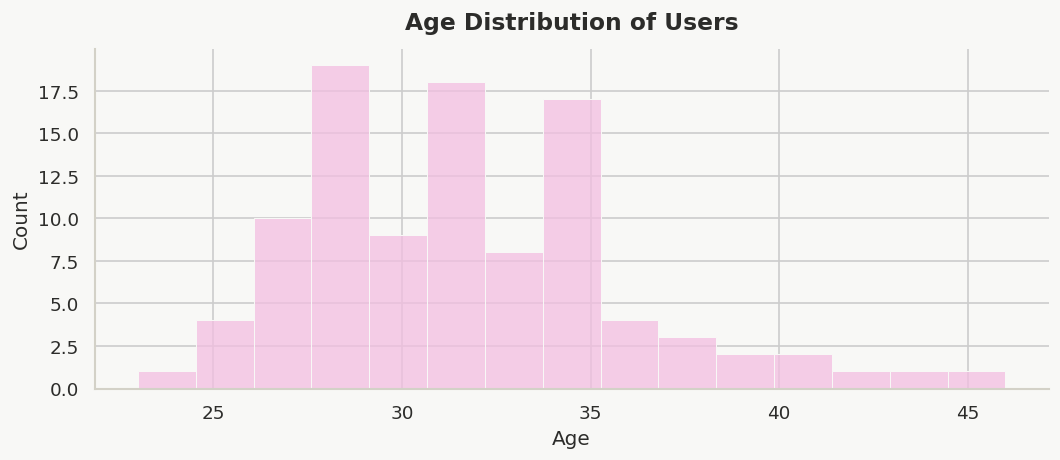

In [31]:
# 1. Age Distribution
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(data=df, x="age", bins=15, color=PINK, edgecolor=BG, linewidth=0.6, ax=ax)
ax.set_title("Age Distribution of Users", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Age")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("visualizations/age_distribution.png", dpi=150)
plt.show()

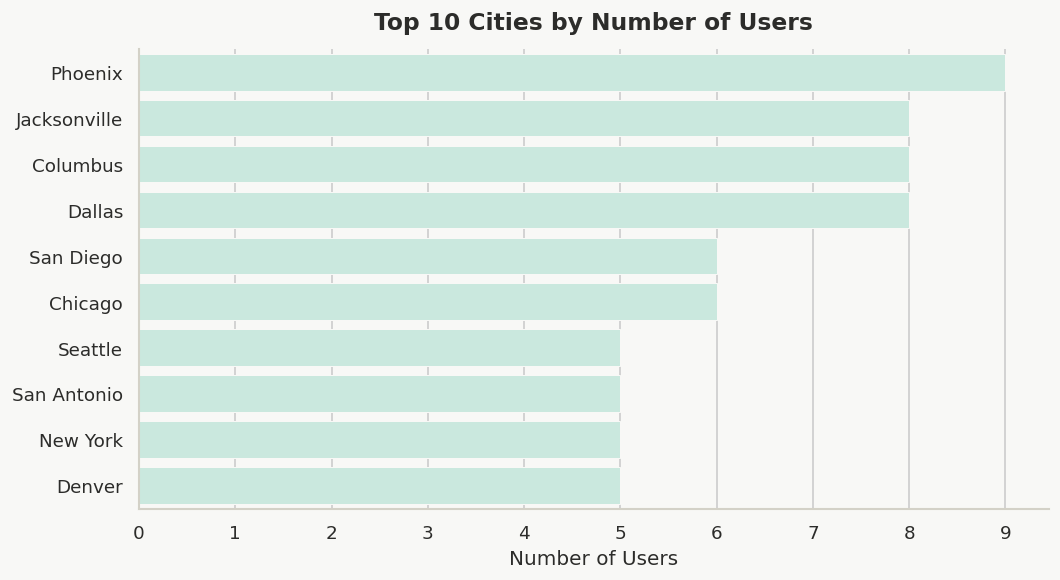

In [ ]:

# 2. Top 10 Cities
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=top_cities.values, y=top_cities.index,
            color=TEAL, edgecolor=BG, linewidth=0.6, ax=ax)
ax.set_title("Top 10 Cities by Number of Users", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Number of Users")
ax.set_ylabel("")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig("visualizations/top_cities.png", dpi=150)
plt.show()

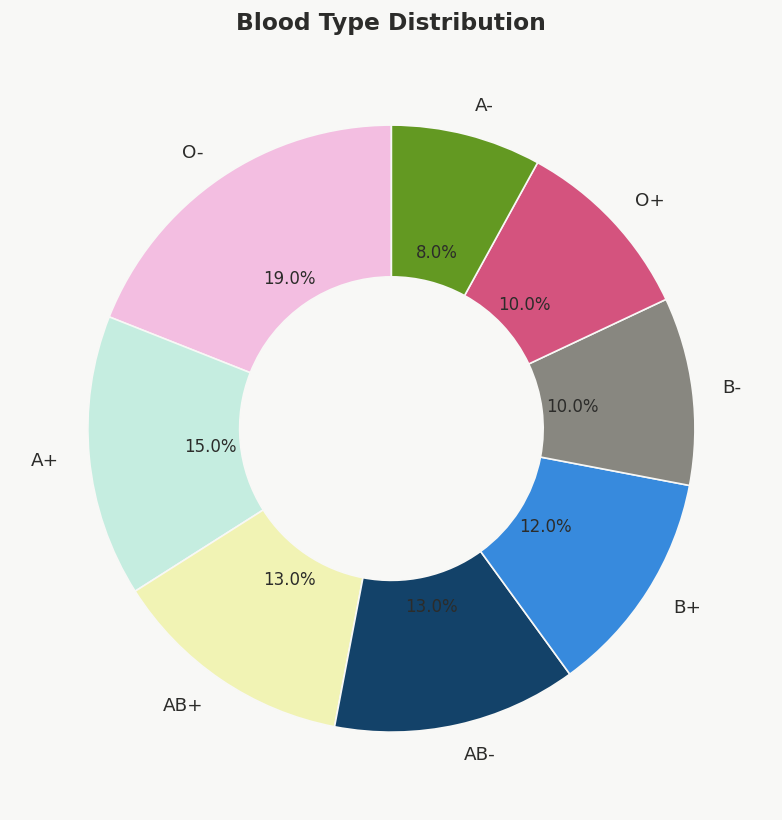

In [37]:
# 3. Blood Type Chart
fig, ax = plt.subplots(figsize=(7, 7))
blood_counts = df['bloodGroup'].value_counts()
wedges, texts, autotexts = ax.pie(
    blood_counts.values,
    labels=blood_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=[PINK, TEAL, YELLOW, NAVY, BLUE, "#888780", "#D4537E", "#639922"],
    wedgeprops=dict(width=0.5, edgecolor=BG)
)
for text in autotexts:
    text.set_fontsize(10)
ax.set_title("Blood Type Distribution", fontsize=14, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("visualizations/blood_type_donut.png", dpi=150)
plt.show()

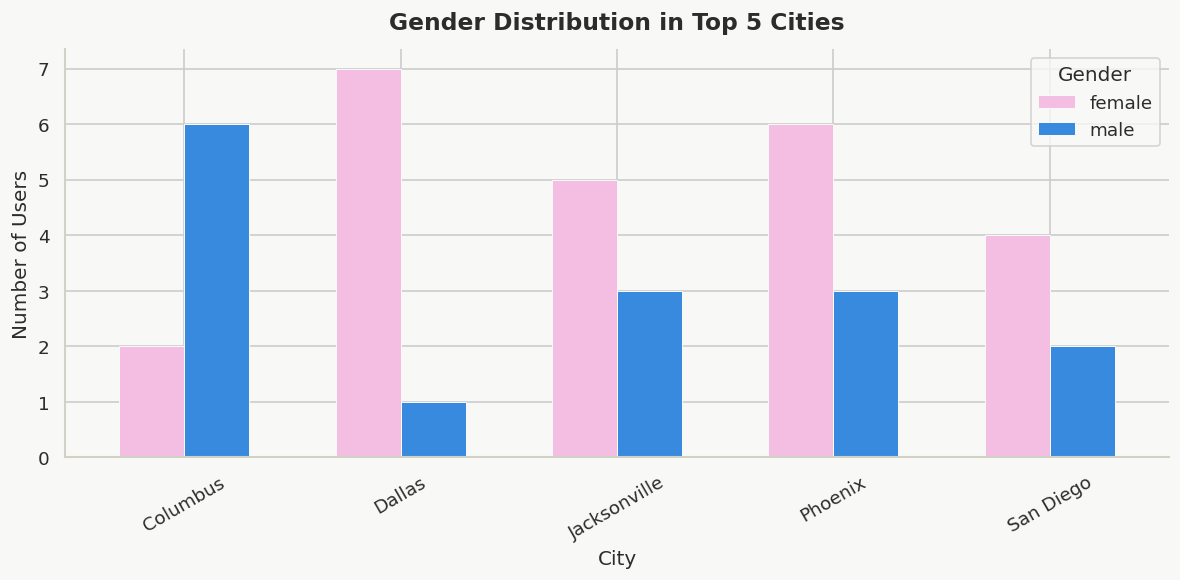

In [39]:
# 4. Gender vs Top 5 Cities Grouped Bar
top5_cities = df['city'].value_counts().head(5).index
df_top5 = df[df['city'].isin(top5_cities)]
fig, ax = plt.subplots(figsize=(10, 5))
city_gender = df_top5.groupby(['city', 'gender']).size().unstack(fill_value=0)
city_gender.plot(kind='bar', ax=ax,
                 color=[PINK, BLUE],
                 edgecolor=BG, linewidth=0.6, width=0.6)
ax.set_title("Gender Distribution in Top 5 Cities", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("City")
ax.set_ylabel("Number of Users")
ax.legend(title="Gender")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("visualizations/gender_top5_cities.png", dpi=150)
plt.show()

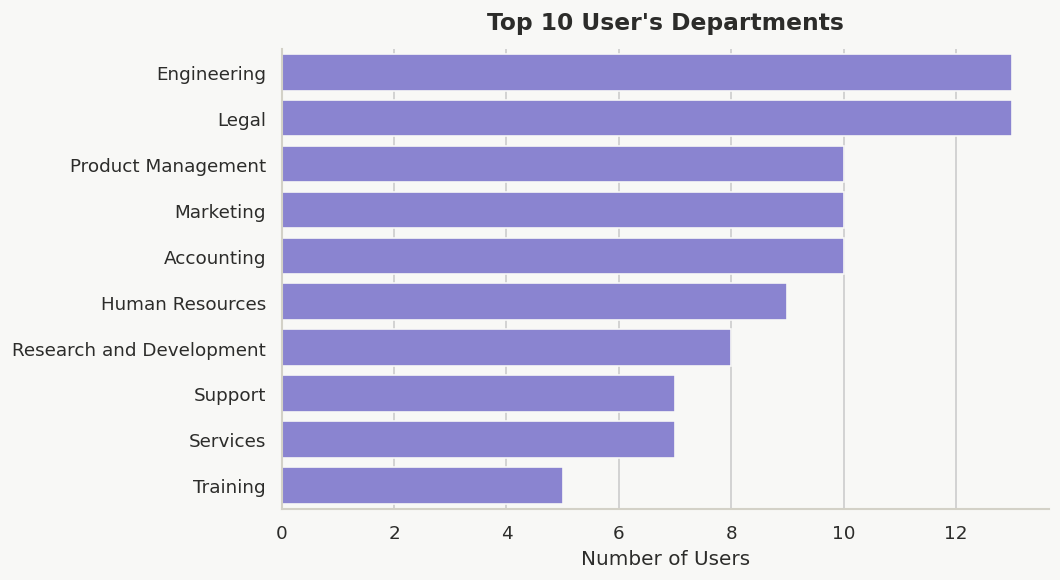

In [45]:
# 5. Top 10 Departments
fig, ax = plt.subplots(figsize=(9, 5))
dept_counts = df['department'].value_counts().head(10)
sns.barplot(x=dept_counts.values, y=dept_counts.index, color=PURPLE, edgecolor=BG, ax=ax)
ax.set_title("Top 10 User's Departments", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Number of Users")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("visualizations/top_departments.png", dpi=150)
plt.show()

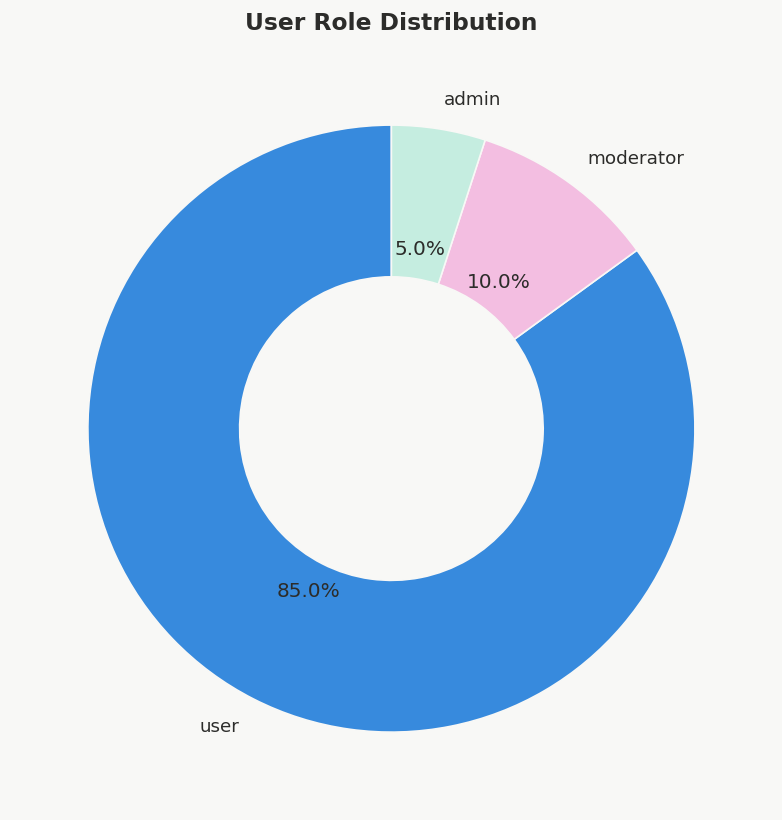

In [46]:

# 6. Role Distribution Donut
fig, ax = plt.subplots(figsize=(7, 7))
role_counts = df['role'].value_counts()
wedges, texts, autotexts = ax.pie(
    role_counts.values,
    labels=role_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=[BLUE, PINK, TEAL],
    wedgeprops=dict(width=0.5, edgecolor=BG)
)
ax.set_title("User Role Distribution", fontsize=14, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("visualizations/role_distribution.png", dpi=150)
plt.show()
